In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Current Directory:", os.getcwd())

/content/drive/MyDrive/Generalizable-DDA-RL
Current Directory: /content/drive/MyDrive/Generalizable-DDA-RL


### ***Imports***

In [6]:
%pip install stable-baselines3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO

from src.environment import GADDAEnv

print("Imports Successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 2.8 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Imports Successful!


### ***Import PPO Model***

In [7]:
MODEL_PATH = "models/ppo_dda"

ppo_model = PPO.load(
    MODEL_PATH,
    device="cpu"
)

print("\nPPO Model Loaded")


PPO Model Loaded


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Load Player Profiles***

In [8]:
PLAYER_PROFILES = {

    "Stable": {
        "initial_skill": 0.5,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },

    "Learning": {
        "initial_skill": 0.3,
        "learning_rate": 0.003,
        "fatigue_rate": 0.0,
        "noise_std": 0.05
    },

    "Fatigue": {
        "initial_skill": 0.8,
        "learning_rate": 0.0,
        "fatigue_rate": 0.002,
        "noise_std": 0.05
    },

    "Noisy": {
        "initial_skill": 0.6,
        "learning_rate": 0.0,
        "fatigue_rate": 0.0,
        "noise_std": 0.15
    }

}

PLAYER_PROFILES

{'Stable': {'initial_skill': 0.5,
  'learning_rate': 0.0,
  'fatigue_rate': 0.0,
  'noise_std': 0.05},
 'Learning': {'initial_skill': 0.3,
  'learning_rate': 0.003,
  'fatigue_rate': 0.0,
  'noise_std': 0.05},
 'Fatigue': {'initial_skill': 0.8,
  'learning_rate': 0.0,
  'fatigue_rate': 0.002,
  'noise_std': 0.05},
 'Noisy': {'initial_skill': 0.6,
  'learning_rate': 0.0,
  'fatigue_rate': 0.0,
  'noise_std': 0.15}}

### ***Define Five Evaluation Methods***
Static Easy   → difficulty 0.2
Static Medium → difficulty 0.5
Static Hard   → difficulty 0.8

Rule-Based DDA

PPO DDA


In [9]:
TARGET_WIN_RATE = 0.70

STATIC_POLICIES = {

    "Static Easy": 0.2,

    "Static Medium": 0.5,

    "Static Hard": 0.8

}

### ***Policy Functions***


In [10]:
def static_policy(
    difficulty
):

    def policy(
        obs,
        env
    ):

        return np.array(
            [difficulty],
            dtype=np.float32
        )

    return policy


def rule_based_policy(
    obs,
    env,
    target_win_rate=0.70,
    tolerance=0.05,
    adjustment=0.08
):

    recent_win_rate = float(
        obs[3]
    )

    current_difficulty = float(
        env.difficulty
    )

    if recent_win_rate > (
        target_win_rate
        +
        tolerance
    ):

        new_difficulty = (
            current_difficulty
            +
            adjustment
        )

    elif recent_win_rate < (
        target_win_rate
        -
        tolerance
    ):

        new_difficulty = (
            current_difficulty
            -
            adjustment
        )

    else:

        new_difficulty = (
            current_difficulty
        )

    new_difficulty = float(
        np.clip(
            new_difficulty,
            0.0,
            1.0
        )
    )

    return np.array(
        [new_difficulty],
        dtype=np.float32
    )


def ppo_policy(
    obs,
    env
):

    action, _ = ppo_model.predict(
        obs,
        deterministic=True
    )

    return action

### ***Main Evaluation Function***

In [11]:
def evaluate_episode(
    method_name,
    policy_function,
    player_config,
    seed,
    max_steps=200,
    target_win_rate=0.70
):

    env = GADDAEnv(
        max_steps=max_steps,
        target_win_rate=target_win_rate,
        player_config=player_config,
        seed=seed
    )

    obs, info = env.reset(
        seed=seed
    )

    difficulties = []
    win_rates = []
    rewards = []
    error_rates = []
    true_skills = []
    estimated_skills = []
    uncertainties = []

    terminated = False
    truncated = False


    while not (
        terminated
        or truncated
    ):

        action = policy_function(
            obs,
            env
        )

        (
            obs,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(
            action
        )

        difficulties.append(
            info["difficulty"]
        )

        win_rates.append(
            info["recent_win_rate"]
        )

        rewards.append(
            reward
        )

        error_rates.append(
            info["error_rate"]
        )

        true_skills.append(
            info["true_skill"]
        )

        estimated_skills.append(
            info["estimated_skill"]
        )

        uncertainties.append(
            info["uncertainty"]
        )


    difficulties = np.array(
        difficulties
    )

    win_rates = np.array(
        win_rates
    )

    rewards = np.array(
        rewards
    )

    error_rates = np.array(
        error_rates
    )


    if len(difficulties) > 1:

        difficulty_changes = np.diff(
            difficulties
        )

        difficulty_change_std = float(
            np.std(
                difficulty_changes
            )
        )

        mean_absolute_difficulty_change = float(
            np.mean(
                np.abs(
                    difficulty_changes
                )
            )
        )

    else:

        difficulty_change_std = 0.0

        mean_absolute_difficulty_change = 0.0


    win_rate_error = float(
        np.mean(
            np.abs(
                win_rates
                -
                target_win_rate
            )
        )
    )


    episode_result = {

        "Method":
            method_name,

        "Seed":
            seed,

        "Win Rate Error":
            win_rate_error,

        "Difficulty Change Std":
            difficulty_change_std,

        "Mean Absolute Difficulty Change":
            mean_absolute_difficulty_change,

        "Episode Length":
            len(
                rewards
            ),

        "Total Reward":
            float(
                np.sum(
                    rewards
                )
            ),

        "Mean Reward":
            float(
                np.mean(
                    rewards
                )
            ),

        "Mean Win Rate":
            float(
                np.mean(
                    win_rates
                )
            ),

        "Final Win Rate":
            float(
                win_rates[-1]
            ),

        "Mean Difficulty":
            float(
                np.mean(
                    difficulties
                )
            ),

        "Final Difficulty":
            float(
                difficulties[-1]
            ),

        "Mean Error Rate":
            float(
                np.mean(
                    error_rates
                )
            )

    }


    trajectory = {

        "difficulty":
            difficulties,

        "win_rate":
            win_rates,

        "reward":
            rewards,

        "error_rate":
            error_rates,

        "true_skill":
            np.array(
                true_skills
            ),

        "estimated_skill":
            np.array(
                estimated_skills
            ),

        "uncertainty":
            np.array(
                uncertainties
            )

    }


    return (
        episode_result,
        trajectory
    )

### ***Quick Test :)***

In [12]:
test_result, test_trajectory = evaluate_episode(
    method_name="PPO DDA",
    policy_function=ppo_policy,
    player_config=PLAYER_PROFILES["Stable"],
    seed=42
)

pd.DataFrame(
    [test_result]
)

,Method,Seed,Win Rate Error,Difficulty Change Std,Mean Absolute Difficulty Change,Episode Length,Total Reward,Mean Reward,Mean Win Rate,Final Win Rate,Mean Difficulty,Final Difficulty,Mean Error Rate
0,PPO DDA,42,0.053794,0.068689,0.058621,200,235.243456,1.176217,0.736127,0.7,0.37426,0.393549,0.012793


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Create All Methods***

In [13]:
METHODS = {

    "Static Easy":
        static_policy(
            STATIC_POLICIES[
                "Static Easy"
            ]
        ),

    "Static Medium":
        static_policy(
            STATIC_POLICIES[
                "Static Medium"
            ]
        ),

    "Static Hard":
        static_policy(
            STATIC_POLICIES[
                "Static Hard"
            ]
        ),

    "Rule-Based DDA":
        rule_based_policy,

    "PPO DDA":
        ppo_policy

}


print(
    "Methods:",
    list(
        METHODS.keys()
    )
)

Methods: ['Static Easy', 'Static Medium', 'Static Hard', 'Rule-Based DDA', 'PPO DDA']


### ***Run Complete Evaluation***

5 methods
×
4 player profiles
×
10 seeds
=
200 evaluation episodes

In [15]:
SEEDS = list(
    range(
        10
    )
)

all_results = []

all_trajectories = {}


for profile_name, player_config in PLAYER_PROFILES.items():

    print(
        "\nEvaluating Profile:",
        profile_name
    )

    all_trajectories[
        profile_name
    ] = {}


    for method_name, policy_function in METHODS.items():

        print(
            "  Running:",
            method_name
        )

        all_trajectories[
            profile_name
        ][
            method_name
        ] = []


        for seed in SEEDS:

            result, trajectory = evaluate_episode(

                method_name=method_name,

                policy_function=policy_function,

                player_config=player_config,

                seed=seed,

                max_steps=200,

                target_win_rate=TARGET_WIN_RATE

            )


            result[
                "Player Profile"
            ] = profile_name


            all_results.append(
                result
            )


            all_trajectories[
                profile_name
            ][
                method_name
            ].append(
                trajectory
            )


print(
    "\nEvaluation Completed"
)


Evaluating Profile: Stable
  Running: Static Easy
  Running: Static Medium
  Running: Static Hard
  Running: Rule-Based DDA
  Running: PPO DDA

Evaluating Profile: Learning
  Running: Static Easy
  Running: Static Medium
  Running: Static Hard
  Running: Rule-Based DDA
  Running: PPO DDA

Evaluating Profile: Fatigue
  Running: Static Easy
  Running: Static Medium
  Running: Static Hard
  Running: Rule-Based DDA
  Running: PPO DDA

Evaluating Profile: Noisy
  Running: Static Easy
  Running: Static Medium
  Running: Static Hard
  Running: Rule-Based DDA
  Running: PPO DDA

Evaluation Completed


### ***Raw Results Dataframe***

In [16]:
results_df = pd.DataFrame(
    all_results
)

results_df = results_df[
    [
        "Player Profile",
        "Method",
        "Seed",
        "Win Rate Error",
        "Difficulty Change Std",
        "Mean Absolute Difficulty Change",
        "Episode Length",
        "Total Reward",
        "Mean Reward",
        "Mean Win Rate",
        "Final Win Rate",
        "Mean Difficulty",
        "Final Difficulty",
        "Mean Error Rate"
    ]
]

results_df.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Player Profile,Method,Seed,Win Rate Error,Difficulty Change Std,Mean Absolute Difficulty Change,Episode Length,Total Reward,Mean Reward,Mean Win Rate,Final Win Rate,Mean Difficulty,Final Difficulty,Mean Error Rate
0,Stable,Static Easy,0,0.178294,0.005541,0.001206,200,143.087161,0.715436,0.865627,1.0,0.206,0.2,0.000053
1,Stable,Static Easy,1,0.219710,0.005541,0.001206,200,110.760788,0.553804,0.898710,0.9,0.206,0.2,0.000000
2,Stable,Static Easy,2,0.198000,0.005541,0.001206,200,129.389630,0.646948,0.898000,0.9,0.206,0.2,0.000000
3,Stable,Static Easy,3,0.211319,0.005541,0.001206,200,120.738169,0.603691,0.910319,0.9,0.206,0.2,0.000154
4,Stable,Static Easy,4,0.209444,0.005541,0.001206,200,121.203887,0.606019,0.901444,0.9,0.206,0.2,0.000190


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
results_df.to_csv(
    "results/evaluation_raw_results.csv",
    index=False
)

print(
    "Results Saved!"
)

Results Saved!


### ***Summary Table***

In [18]:
summary_df = (

    results_df

    .groupby(
        [
            "Player Profile",
            "Method"
        ]
    )

    .agg(

        Win_Rate_Error=(
            "Win Rate Error",
            "mean"
        ),

        Difficulty_Change_Std=(
            "Difficulty Change Std",
            "mean"
        ),

        Mean_Absolute_Difficulty_Change=(
            "Mean Absolute Difficulty Change",
            "mean"
        ),

        Episode_Length=(
            "Episode Length",
            "mean"
        ),

        Total_Reward=(
            "Total Reward",
            "mean"
        ),

        Mean_Win_Rate=(
            "Mean Win Rate",
            "mean"
        ),

        Mean_Difficulty=(
            "Mean Difficulty",
            "mean"
        ),

        Mean_Error_Rate=(
            "Mean Error Rate",
            "mean"
        )

    )

    .reset_index()

)

summary_df

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Player Profile,Method,Win_Rate_Error,Difficulty_Change_Std,Mean_Absolute_Difficulty_Change,Episode_Length,Total_Reward,Mean_Win_Rate,Mean_Difficulty,Mean_Error_Rate
0,Fatigue,PPO DDA,0.088164,0.070230,0.058630,200.0,206.514811,0.748531,0.427139,0.015185
1,Fatigue,Rule-Based DDA,0.135132,0.014031,0.012406,200.0,170.398901,0.675690,0.482552,0.014699
2,Fatigue,Static Easy,0.247396,0.005541,0.001206,200.0,94.027230,0.945063,0.206000,0.000115
3,Fatigue,Static Hard,0.499859,0.005541,0.001206,200.0,-259.153375,0.210827,0.794000,0.239923
4,Fatigue,Static Medium,0.196394,0.000000,0.000000,200.0,118.232770,0.652294,0.500000,0.029654
5,Learning,PPO DDA,0.094919,0.068567,0.056892,200.0,198.264469,0.741600,0.427643,0.014338
6,Learning,Rule-Based DDA,0.146835,0.014109,0.012523,200.0,155.793893,0.694065,0.465886,0.016423
7,Learning,Static Easy,0.236116,0.005541,0.001206,200.0,98.060159,0.889548,0.206000,0.003551
8,Learning,Static Hard,0.478275,0.005541,0.001206,200.0,-241.879576,0.224625,0.794000,0.239595
9,Learning,Static Medium,0.265681,0.000000,0.000000,200.0,44.277984,0.609819,0.500000,0.051455


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Round Summary for Easier Viewing***

In [19]:
display_summary = summary_df.copy()

numeric_columns = [

    "Win_Rate_Error",

    "Difficulty_Change_Std",

    "Mean_Absolute_Difficulty_Change",

    "Episode_Length",

    "Total_Reward",

    "Mean_Win_Rate",

    "Mean_Difficulty",

    "Mean_Error_Rate"

]

display_summary[
    numeric_columns
] = display_summary[
    numeric_columns
].round(
    4
)


display_summary

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Player Profile,Method,Win_Rate_Error,Difficulty_Change_Std,Mean_Absolute_Difficulty_Change,Episode_Length,Total_Reward,Mean_Win_Rate,Mean_Difficulty,Mean_Error_Rate
0,Fatigue,PPO DDA,0.0882,0.0702,0.0586,200.0,206.5148,0.7485,0.4271,0.0152
1,Fatigue,Rule-Based DDA,0.1351,0.0140,0.0124,200.0,170.3989,0.6757,0.4826,0.0147
2,Fatigue,Static Easy,0.2474,0.0055,0.0012,200.0,94.0272,0.9451,0.2060,0.0001
3,Fatigue,Static Hard,0.4999,0.0055,0.0012,200.0,-259.1534,0.2108,0.7940,0.2399
4,Fatigue,Static Medium,0.1964,0.0000,0.0000,200.0,118.2328,0.6523,0.5000,0.0297
5,Learning,PPO DDA,0.0949,0.0686,0.0569,200.0,198.2645,0.7416,0.4276,0.0143
6,Learning,Rule-Based DDA,0.1468,0.0141,0.0125,200.0,155.7939,0.6941,0.4659,0.0164
7,Learning,Static Easy,0.2361,0.0055,0.0012,200.0,98.0602,0.8895,0.2060,0.0036
8,Learning,Static Hard,0.4783,0.0055,0.0012,200.0,-241.8796,0.2246,0.7940,0.2396
9,Learning,Static Medium,0.2657,0.0000,0.0000,200.0,44.2780,0.6098,0.5000,0.0515


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
summary_df.to_csv(
    "results/evaluation_summary.csv",
    index=False
)

print(
    "Summary Results Saved!"
)

Summary Results Saved!


# ***Figures***

### ***Mean win rate error for every profile***

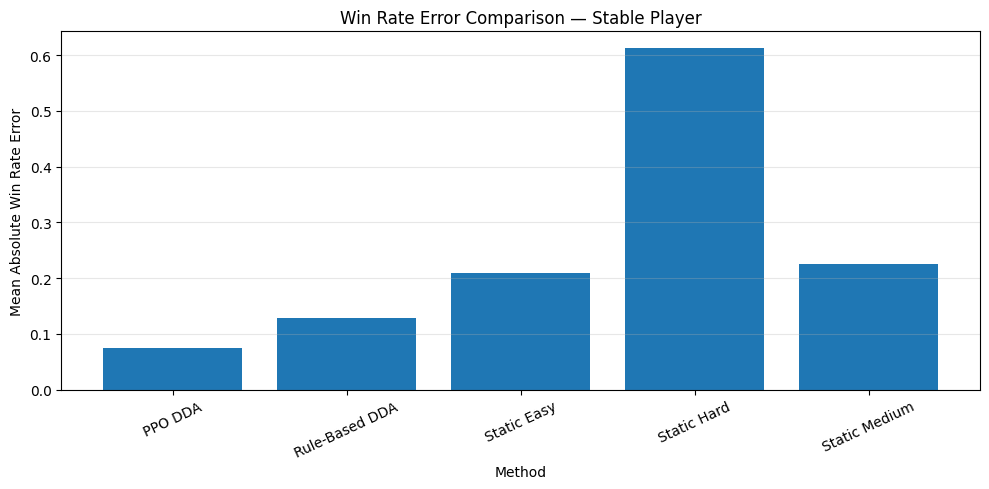

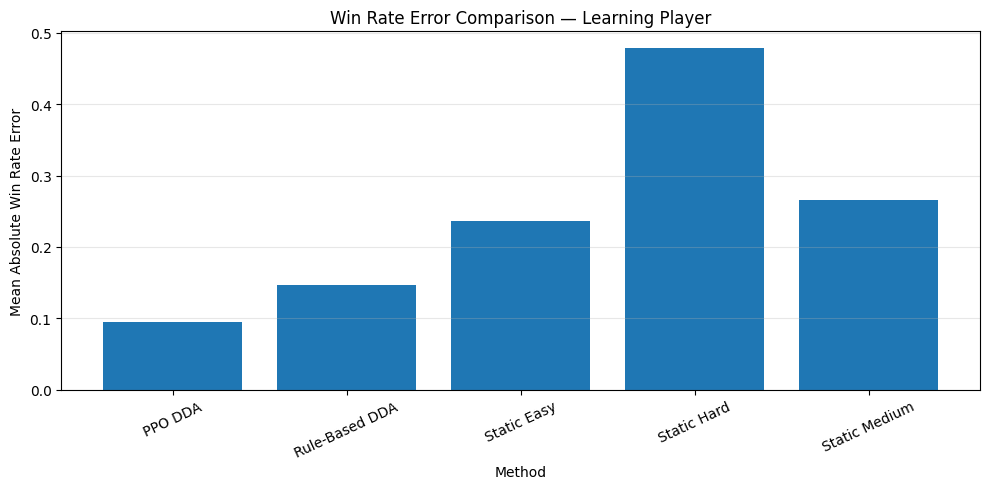

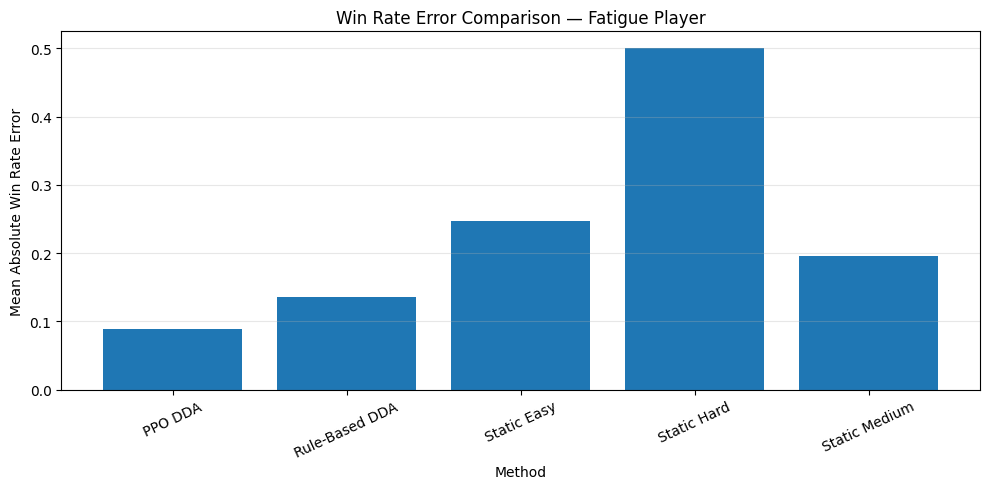

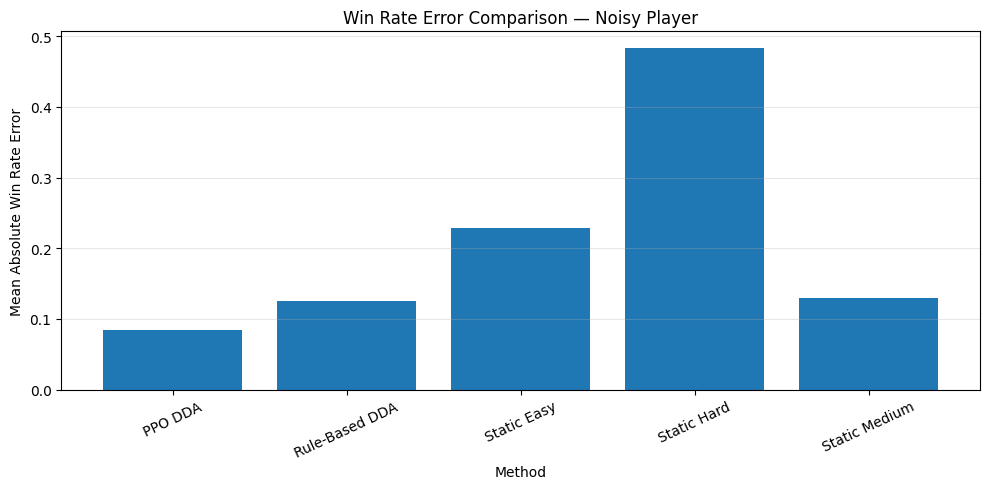

In [21]:
profiles = list(
    PLAYER_PROFILES.keys()
)

methods = list(
    METHODS.keys()
)


for profile_name in profiles:

    profile_data = summary_df[
        summary_df[
            "Player Profile"
        ]
        ==
        profile_name
    ]

    plt.figure(
        figsize=(10, 5)
    )

    plt.bar(
        profile_data[
            "Method"
        ],

        profile_data[
            "Win_Rate_Error"
        ]
    )

    plt.xlabel(
        "Method"
    )

    plt.ylabel(
        "Mean Absolute Win Rate Error"
    )

    plt.title(
        f"Win Rate Error Comparison — {profile_name} Player"
    )

    plt.xticks(
        rotation=25
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        f"figures/win_rate_error_{profile_name.lower()}.png",
        dpi=300
    )

    plt.show()

### ***Overall Win-Rate-Error Comparison***

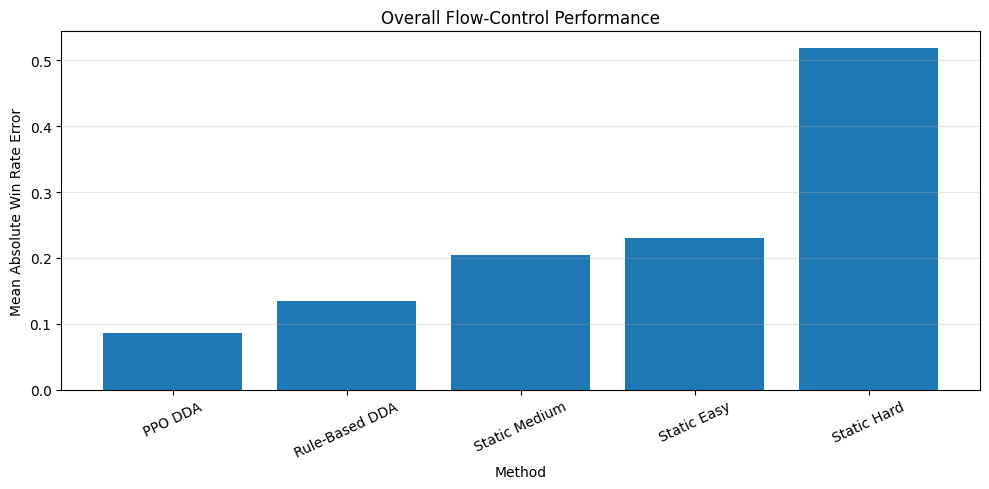

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
overall_win_error = (

    results_df

    .groupby(
        "Method"
    )[
        "Win Rate Error"
    ]

    .mean()

    .sort_values()

)


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    overall_win_error.index,
    overall_win_error.values
)

plt.xlabel(
    "Method"
)

plt.ylabel(
    "Mean Absolute Win Rate Error"
)

plt.title(
    "Overall Flow-Control Performance"
)

plt.xticks(
    rotation=25
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/overall_win_rate_error.png",
    dpi=300
)

plt.show()

### ***Difficulty Smoothness Comparison***

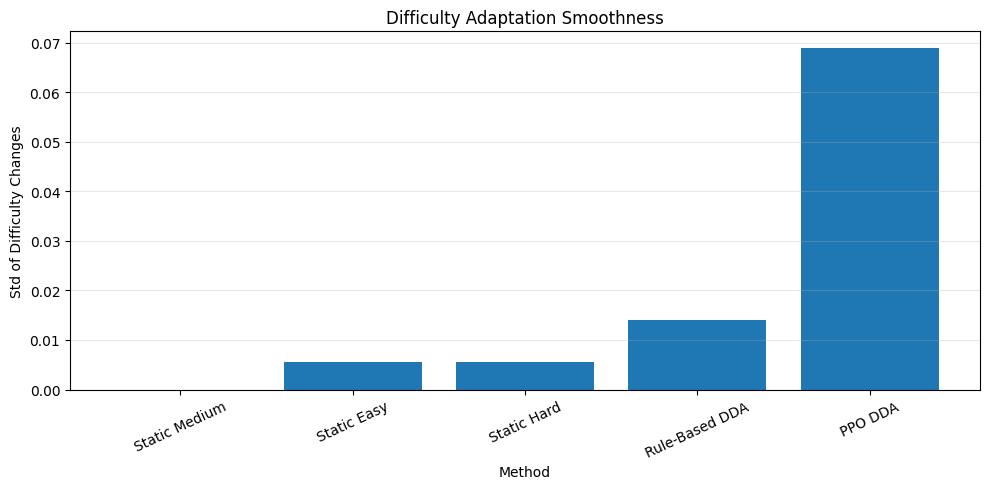

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
overall_smoothness = (

    results_df

    .groupby(
        "Method"
    )[
        "Difficulty Change Std"
    ]

    .mean()

    .sort_values()

)


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    overall_smoothness.index,
    overall_smoothness.values
)

plt.xlabel(
    "Method"
)

plt.ylabel(
    "Std of Difficulty Changes"
)

plt.title(
    "Difficulty Adaptation Smoothness"
)

plt.xticks(
    rotation=25
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/difficulty_smoothness.png",
    dpi=300
)

plt.show()

### ***Mean Reward Comparison***

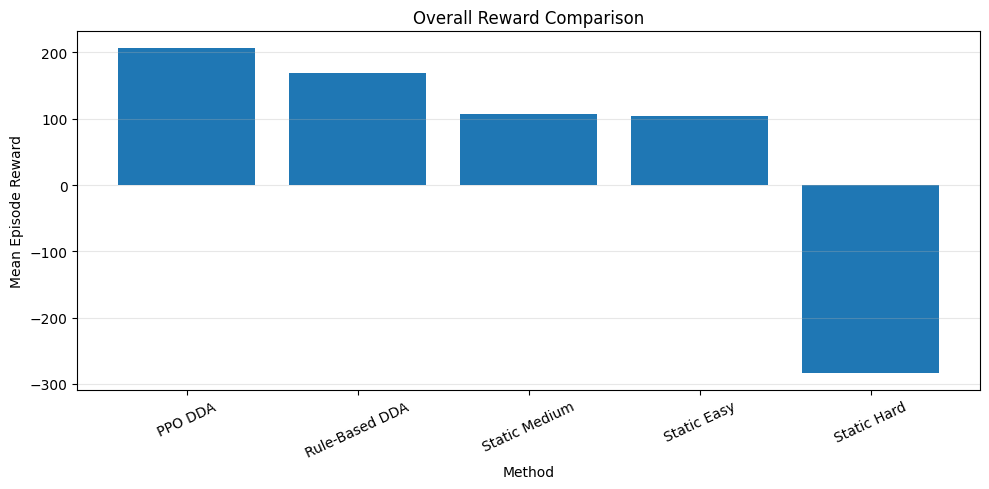

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
overall_reward = (

    results_df

    .groupby(
        "Method"
    )[
        "Total Reward"
    ]

    .mean()

    .sort_values(
        ascending=False
    )

)


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    overall_reward.index,
    overall_reward.values
)

plt.xlabel(
    "Method"
)

plt.ylabel(
    "Mean Episode Reward"
)

plt.title(
    "Overall Reward Comparison"
)

plt.xticks(
    rotation=25
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/overall_reward.png",
    dpi=300
)

plt.show()

### ***Plot Representative Trajectories***

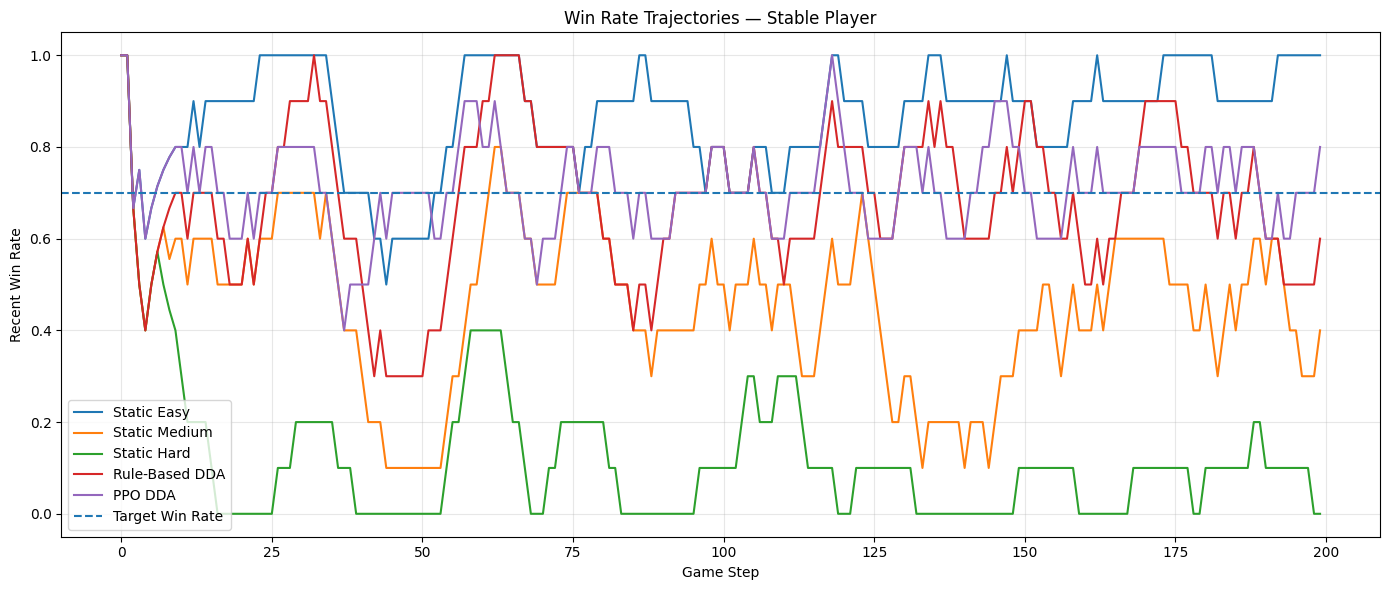

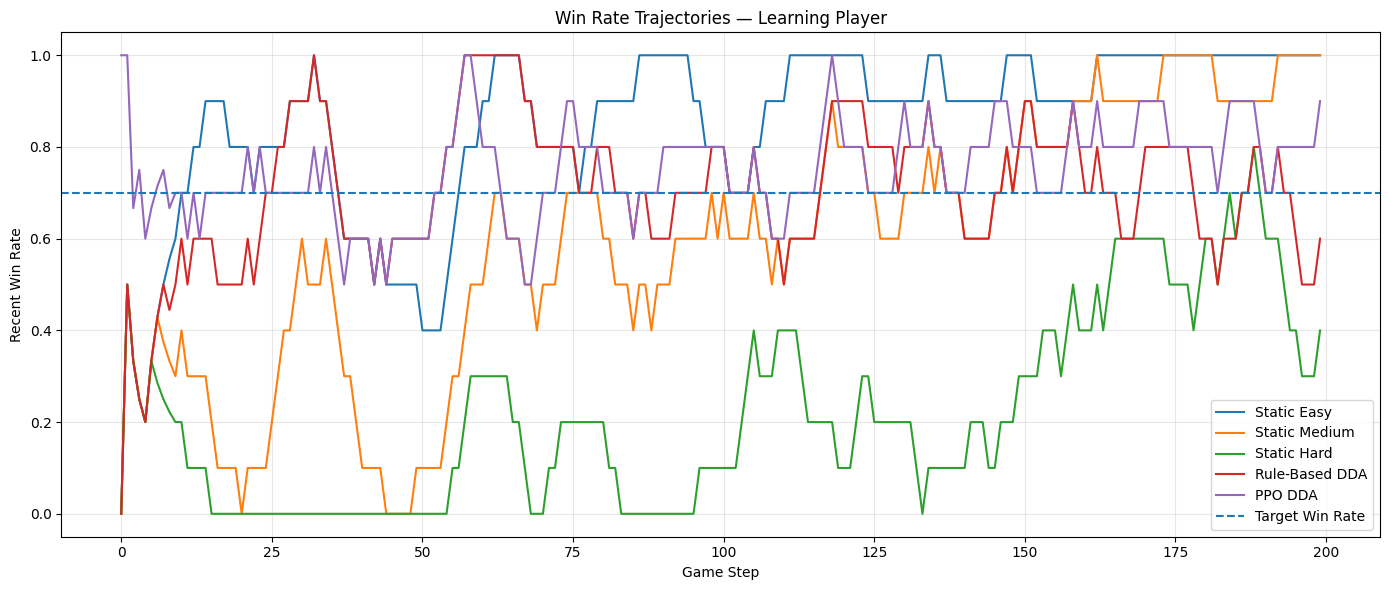

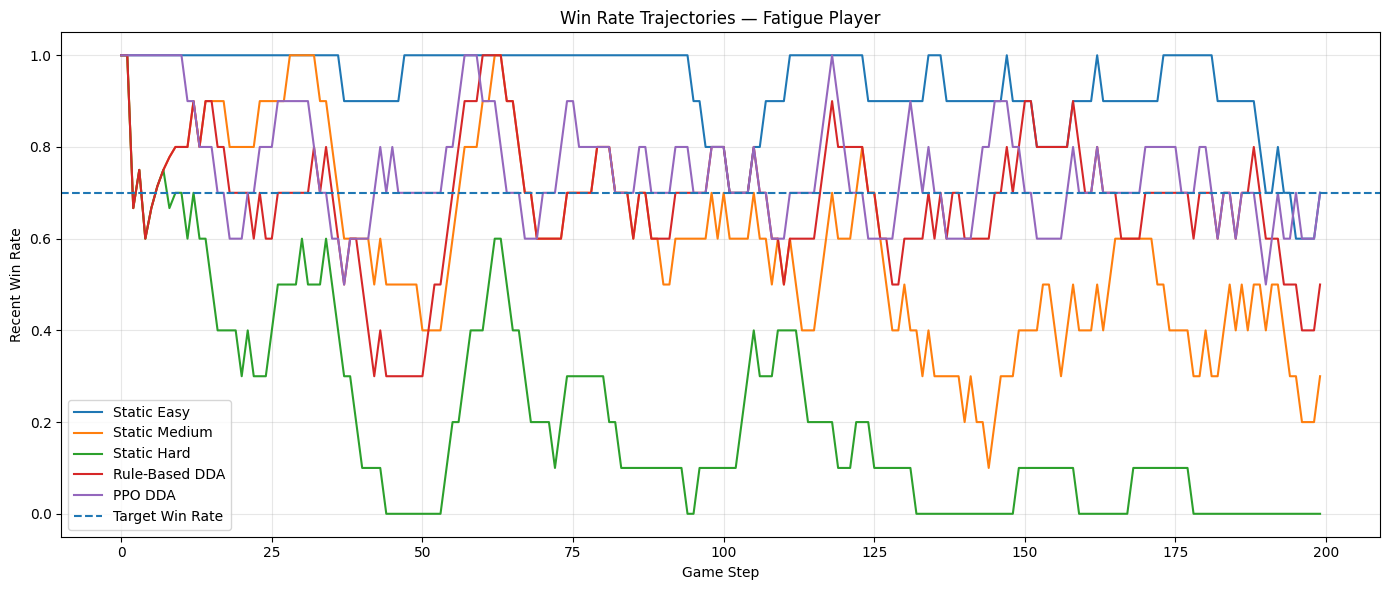

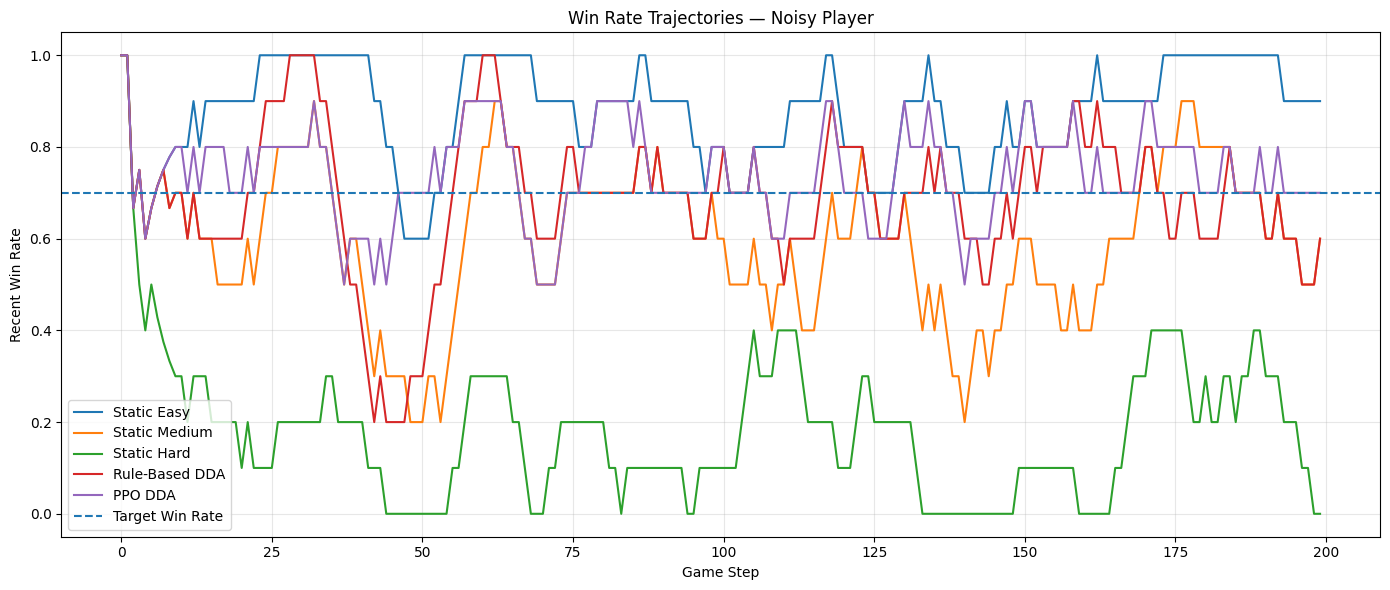

In [26]:
for profile_name in profiles:

    plt.figure(
        figsize=(14, 6)
    )

    for method_name in methods:

        trajectory = all_trajectories[
            profile_name
        ][
            method_name
        ][0]

        plt.plot(
            trajectory[
                "win_rate"
            ],
            label=method_name
        )


    plt.axhline(
        TARGET_WIN_RATE,
        linestyle="--",
        label="Target Win Rate"
    )


    plt.xlabel(
        "Game Step"
    )

    plt.ylabel(
        "Recent Win Rate"
    )

    plt.title(
        f"Win Rate Trajectories — {profile_name} Player"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        f"figures/win_rate_trajectory_{profile_name.lower()}.png",
        dpi=300
    )

    plt.show()

### ***Difficulty Adaptation Trajectories***

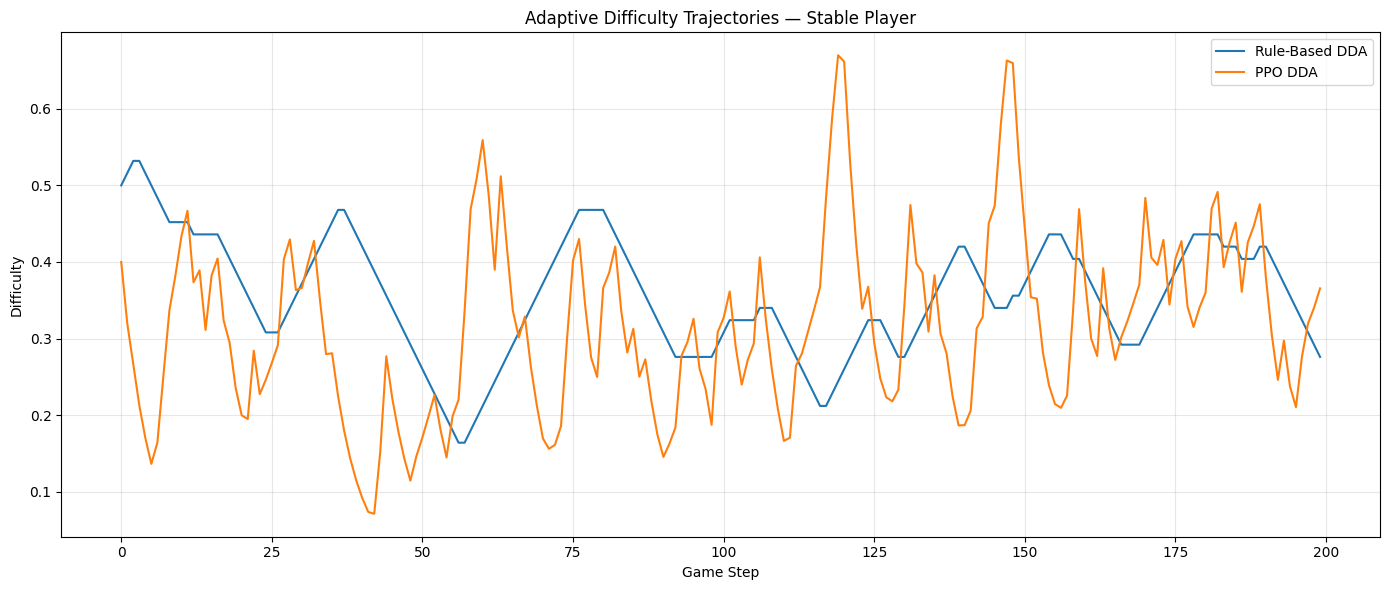

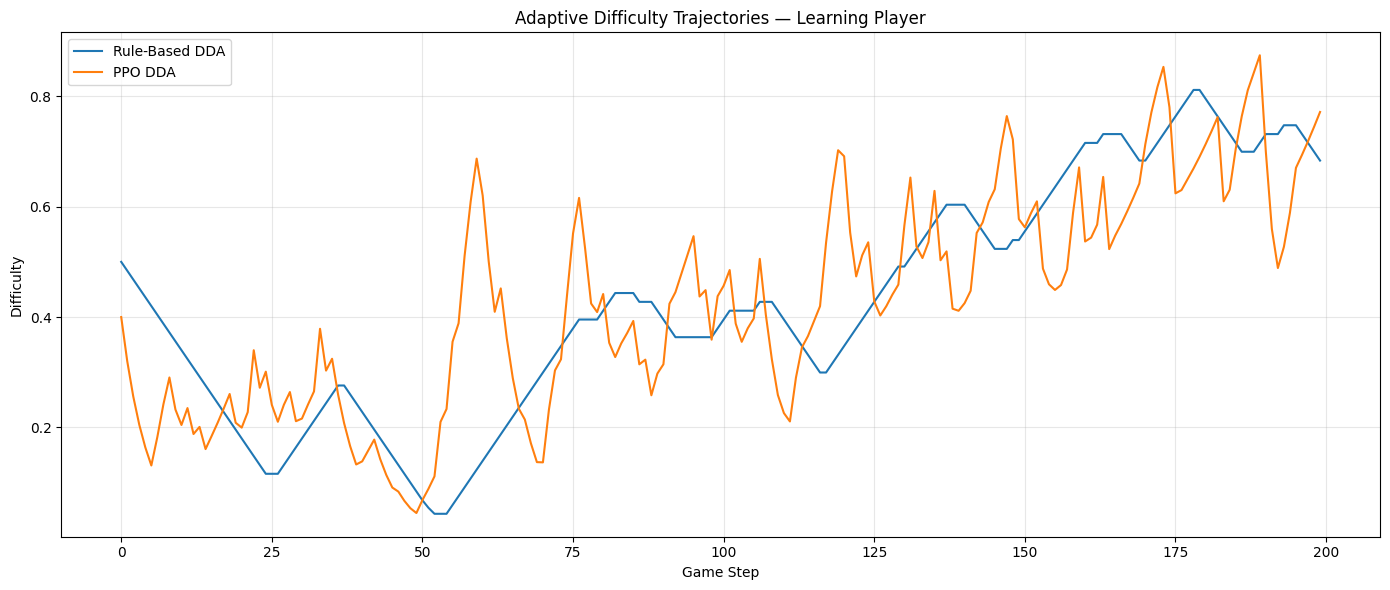

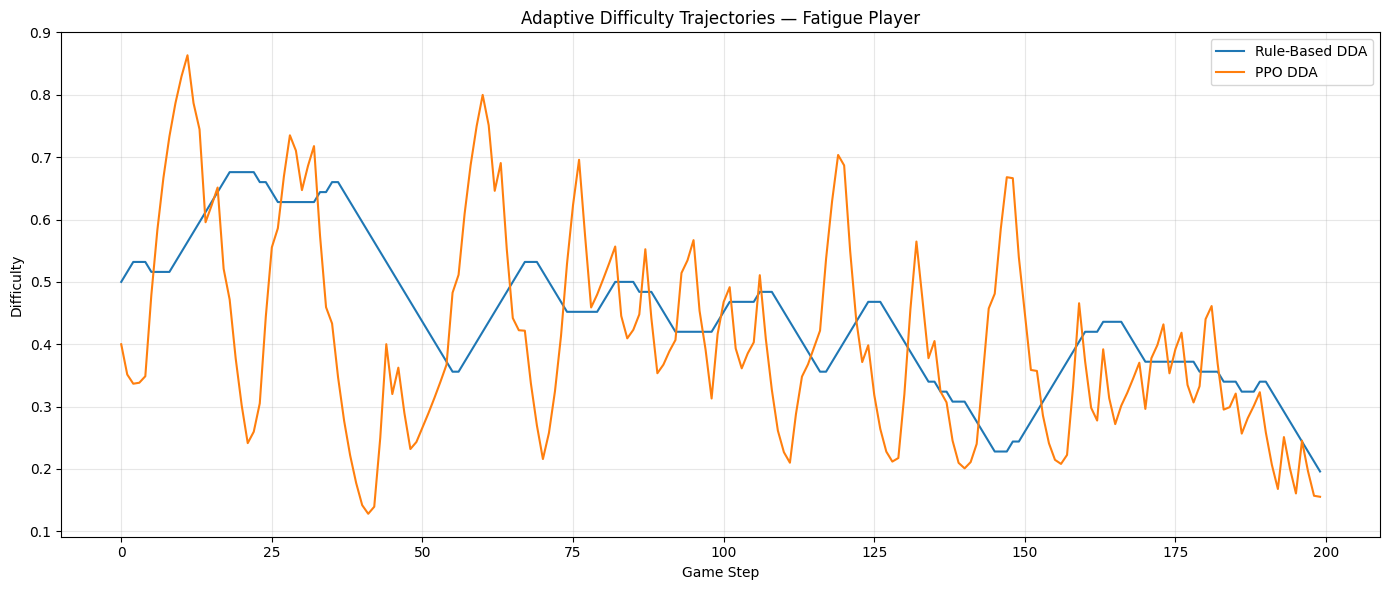

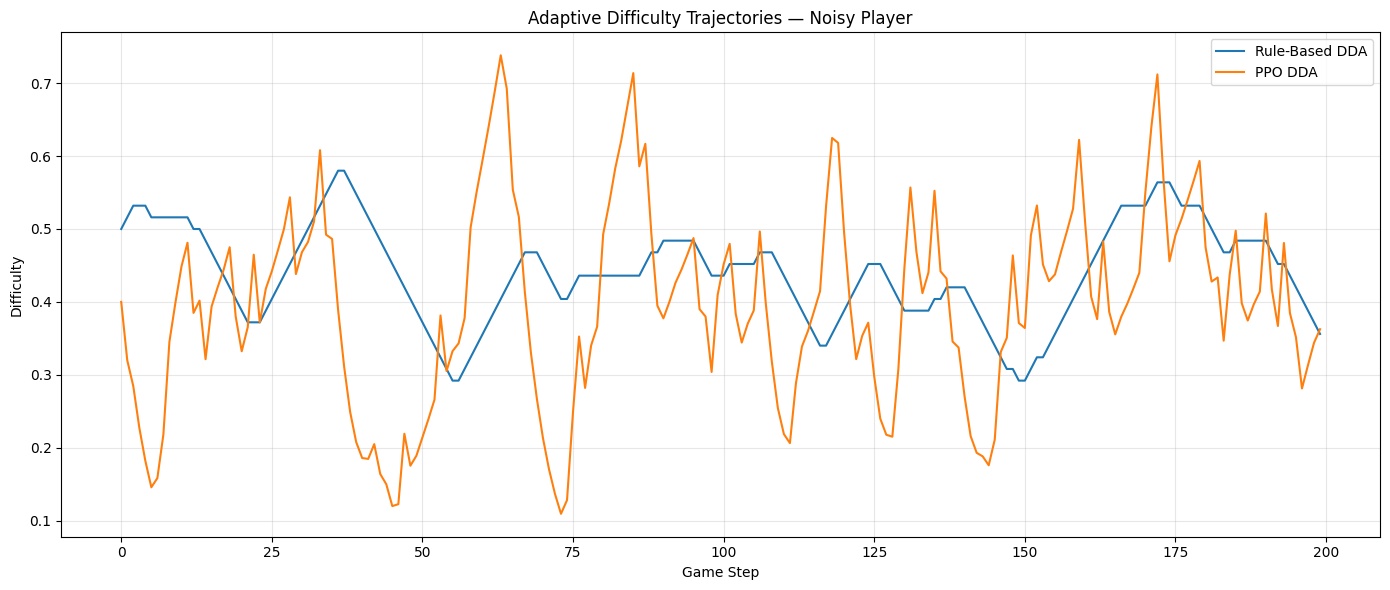

In [27]:
ADAPTIVE_METHODS = [

    "Rule-Based DDA",

    "PPO DDA"

]


for profile_name in profiles:

    plt.figure(
        figsize=(14, 6)
    )

    for method_name in ADAPTIVE_METHODS:

        trajectory = all_trajectories[
            profile_name
        ][
            method_name
        ][0]

        plt.plot(
            trajectory[
                "difficulty"
            ],
            label=method_name
        )


    plt.xlabel(
        "Game Step"
    )

    plt.ylabel(
        "Difficulty"
    )

    plt.title(
        f"Adaptive Difficulty Trajectories — {profile_name} Player"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        f"figures/difficulty_trajectory_{profile_name.lower()}.png",
        dpi=300
    )

    plt.show()

### ***PPO vs Rule Based Summary***

In [28]:
adaptive_summary = summary_df[
    summary_df[
        "Method"
    ].isin(
        [
            "PPO DDA",
            "Rule-Based DDA"
        ]
    )
]


adaptive_summary[
    [
        "Player Profile",
        "Method",
        "Win_Rate_Error",
        "Difficulty_Change_Std",
        "Mean_Absolute_Difficulty_Change",
        "Total_Reward",
        "Mean_Win_Rate"
    ]
].round(
    4
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Player Profile,Method,Win_Rate_Error,Difficulty_Change_Std,Mean_Absolute_Difficulty_Change,Total_Reward,Mean_Win_Rate
0,Fatigue,PPO DDA,0.0882,0.0702,0.0586,206.5148,0.7485
1,Fatigue,Rule-Based DDA,0.1351,0.0140,0.0124,170.3989,0.6757
5,Learning,PPO DDA,0.0949,0.0686,0.0569,198.2645,0.7416
6,Learning,Rule-Based DDA,0.1468,0.0141,0.0125,155.7939,0.6941
10,Noisy,PPO DDA,0.0843,0.0703,0.0590,208.0911,0.7413
11,Noisy,Rule-Based DDA,0.1254,0.0137,0.0118,177.6321,0.6912
15,Stable,PPO DDA,0.0745,0.0662,0.0559,216.4778,0.7180
16,Stable,Rule-Based DDA,0.1286,0.0140,0.0123,175.3336,0.6819


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Overall Ranking Table***

In [29]:
ranking_df = (

    results_df

    .groupby(
        "Method"
    )

    .agg(

        Mean_Win_Rate_Error=(
            "Win Rate Error",
            "mean"
        ),

        Std_Win_Rate_Error=(
            "Win Rate Error",
            "std"
        ),

        Mean_Difficulty_Change_Std=(
            "Difficulty Change Std",
            "mean"
        ),

        Mean_Total_Reward=(
            "Total Reward",
            "mean"
        )

    )

    .reset_index()

    .sort_values(
        "Mean_Win_Rate_Error"
    )

)


ranking_df = ranking_df.round(
    4
)

ranking_df

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Method,Mean_Win_Rate_Error,Std_Win_Rate_Error,Mean_Difficulty_Change_Std,Mean_Total_Reward
0,PPO DDA,0.0855,0.0103,0.0688,207.3371
1,Rule-Based DDA,0.1340,0.0176,0.0140,169.7896
4,Static Medium,0.2045,0.0545,0.0000,106.6023
2,Static Easy,0.2303,0.0222,0.0055,104.8669
3,Static Hard,0.5183,0.0611,0.0055,-283.8857


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### ***Final Best Method***

In [30]:
best_method = ranking_df.iloc[0]

print(
    "Best Method by Mean Win Rate Error:"
)

print(
    best_method["Method"]
)

print()

print(
    "Mean Win Rate Error:",
    best_method[
        "Mean_Win_Rate_Error"
    ]
)

Best Method by Mean Win Rate Error:
PPO DDA

Mean Win Rate Error: 0.0855


In [31]:
print("Results files:")
!ls -lh results/

print("\nFigures:")
!ls -lh figures/

Results files:
total 58K
-rw------- 1 root root  38K Sep  8 18:37 evaluation_raw_results.csv
-rw------- 1 root root 3.2K Sep  8 18:39 evaluation_summary.csv
drwx------ 2 root root 4.0K Sep  7 14:26 figures
drwx------ 2 root root 4.0K Sep  7 14:26 tables
drwx------ 2 root root 4.0K Sep  8 09:15 training
drwx------ 2 root root 4.0K Sep  7 14:26 trajectories

Figures:
total 4.5M
-rw------- 1 root root 150K Sep  8 18:44 difficulty_smoothness.png
-rw------- 1 root root 385K Sep  8 18:48 difficulty_trajectory_fatigue.png
-rw------- 1 root root 355K Sep  8 18:48 difficulty_trajectory_learning.png
-rw------- 1 root root 396K Sep  8 18:48 difficulty_trajectory_noisy.png
-rw------- 1 root root 404K Sep  8 18:48 difficulty_trajectory_stable.png
-rw------- 1 root root 138K Sep  8 18:47 overall_reward.png
-rw------- 1 root root 139K Sep  8 18:42 overall_win_rate_error.png
-rw------- 1 root root 140K Sep  8 18:39 win_rate_error_fatigue.png
-rw------- 1 root root 141K Sep  8 18:39 win_rate_error_lear